In [7]:
import random
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

def roll_die(dice_to_throw):
    throw = []
    for i in range(dice_to_throw):
        roll = random.randint(1, 6)
        throw.append(roll)
    max_throw = max(throw)
    return max_throw, throw

def fight_resolver():
    if my_fight_value > enemy_fight_value:
        if my_max_throw >= enemy_max_throw:
            return "You win!"
        else:
            return "The enemy wins!"
    elif my_fight_value < enemy_fight_value:
        if enemy_max_throw >= my_max_throw:
            return "The enemy wins!"
        else:
            return "You win!"
    else:
        if my_fight_value == enemy_fight_value:
            if my_max_throw > enemy_max_throw:
                return "You win!"
            elif my_max_throw < enemy_max_throw:
                return "The enemy wins!"
            else:
                return "It's Roll Off! The fight values and throws are equal."
    
def fight_value_checker(fight_value):
    if fight_value < 1:
        print("Fight value must be at least 1.")
    elif fight_value > 10:
        print("Fight value cannot exceed 10.")

def win_rate_simulation(my_fv, enemy_fv, my_dice, enemy_dice, simulations = 1000):
    my_wins = 0
    my_losses = 0

    for i in range(simulations):
        my_max_throw, _ = roll_die(my_dice)
        enemy_max_throw, _ = roll_die(enemy_dice)
        
        if my_fv > enemy_fv:
            if my_max_throw >= enemy_max_throw:
                my_wins += 1
            else:
                my_losses += 1
        elif my_fv < enemy_fv:
            if enemy_max_throw >= my_max_throw:
                my_losses += 1
            else:
                my_wins += 1
        else:
            if my_max_throw > enemy_max_throw:
                my_wins += 1
            elif my_max_throw < enemy_max_throw:
                my_losses += 1
            else:
                roll_off = random.randint(1, 6)
                if roll_off <= 3:
                    my_wins += 1
                else:
                    my_losses += 1
    
    win_rate = my_wins / simulations
    loss_rate = my_losses / simulations

    return win_rate, loss_rate

In [2]:
#My Throws
my_fight_value = int(input("What is your fight value? "))
fight_value_checker(my_fight_value)

dice_thrown = int(input("How many dice do you want to throw? "))
my_max_throw, my_throw = roll_die(dice_thrown)

print("Your throw was", my_throw)
print("Your highest throw was", my_max_throw)

#Enemy Throws
enemy_fight_value = int(input("What is the enemy's fight value? "))
fight_value_checker(enemy_fight_value)

enemy_dice_thrown = int(input("How many dice does the enemy want to throw? "))
enemy_max_throw, enemy_throw = roll_die(enemy_dice_thrown)

print("The enemy's throw was", enemy_throw)
print("The enemy's highest throw was", enemy_max_throw)

#Determine the winner
result = fight_resolver()
print(result)

Your throw was [5, 3, 1, 3, 5, 2, 6]
Your highest throw was 6
The enemy's throw was [1, 6, 4, 6]
The enemy's highest throw was 6
You win!


In [8]:
# Initialize list to collect results
results = []

'''
There is no need to run simulations for every possible fight value combinations
We can run three types of simulations 
1,1, where fv are equal
1,2, where enemy has higher fv
2,1, where player has higher fv
'''

scenarios = [
    [1, 1],
    [1, 2],
    [2, 1]
]

for scenario in scenarios:
    if scenario[0] < scenario[1]:
        scenario_simulation = "Enemy has higher fight value"
    elif scenario[0] > scenario[1]:
        scenario_simulation = "You have higher fight value"
    else:
        scenario_simulation = "Fight values are equal"

    my_fv, enemy_fv = scenario
    for i in range(1, 11):
        for j in range(1, 11):
            win_rate, loss_rate = win_rate_simulation(my_fv, enemy_fv, i, j, 1000)

            # Add result to list
            results.append({
                "Scenario": scenario_simulation,
                "Win Rate": f"{win_rate:.2%}",
                "My Dice": i,
                "Enemy Dice": j
            })

# Create DataFrame from collected results
df = pd.DataFrame(results)
df

,Scenario,Win Rate,My Dice,Enemy Dice
0,Fight values are equal,51.00%,1,1
1,Fight values are equal,31.70%,1,2
2,Fight values are equal,25.60%,1,3
3,Fight values are equal,23.90%,1,4
4,Fight values are equal,18.30%,1,5
...,...,...,...,...
295,You have higher fight value,88.70%,10,6
296,You have higher fight value,89.00%,10,7
297,You have higher fight value,87.90%,10,8
298,You have higher fight value,85.80%,10,9


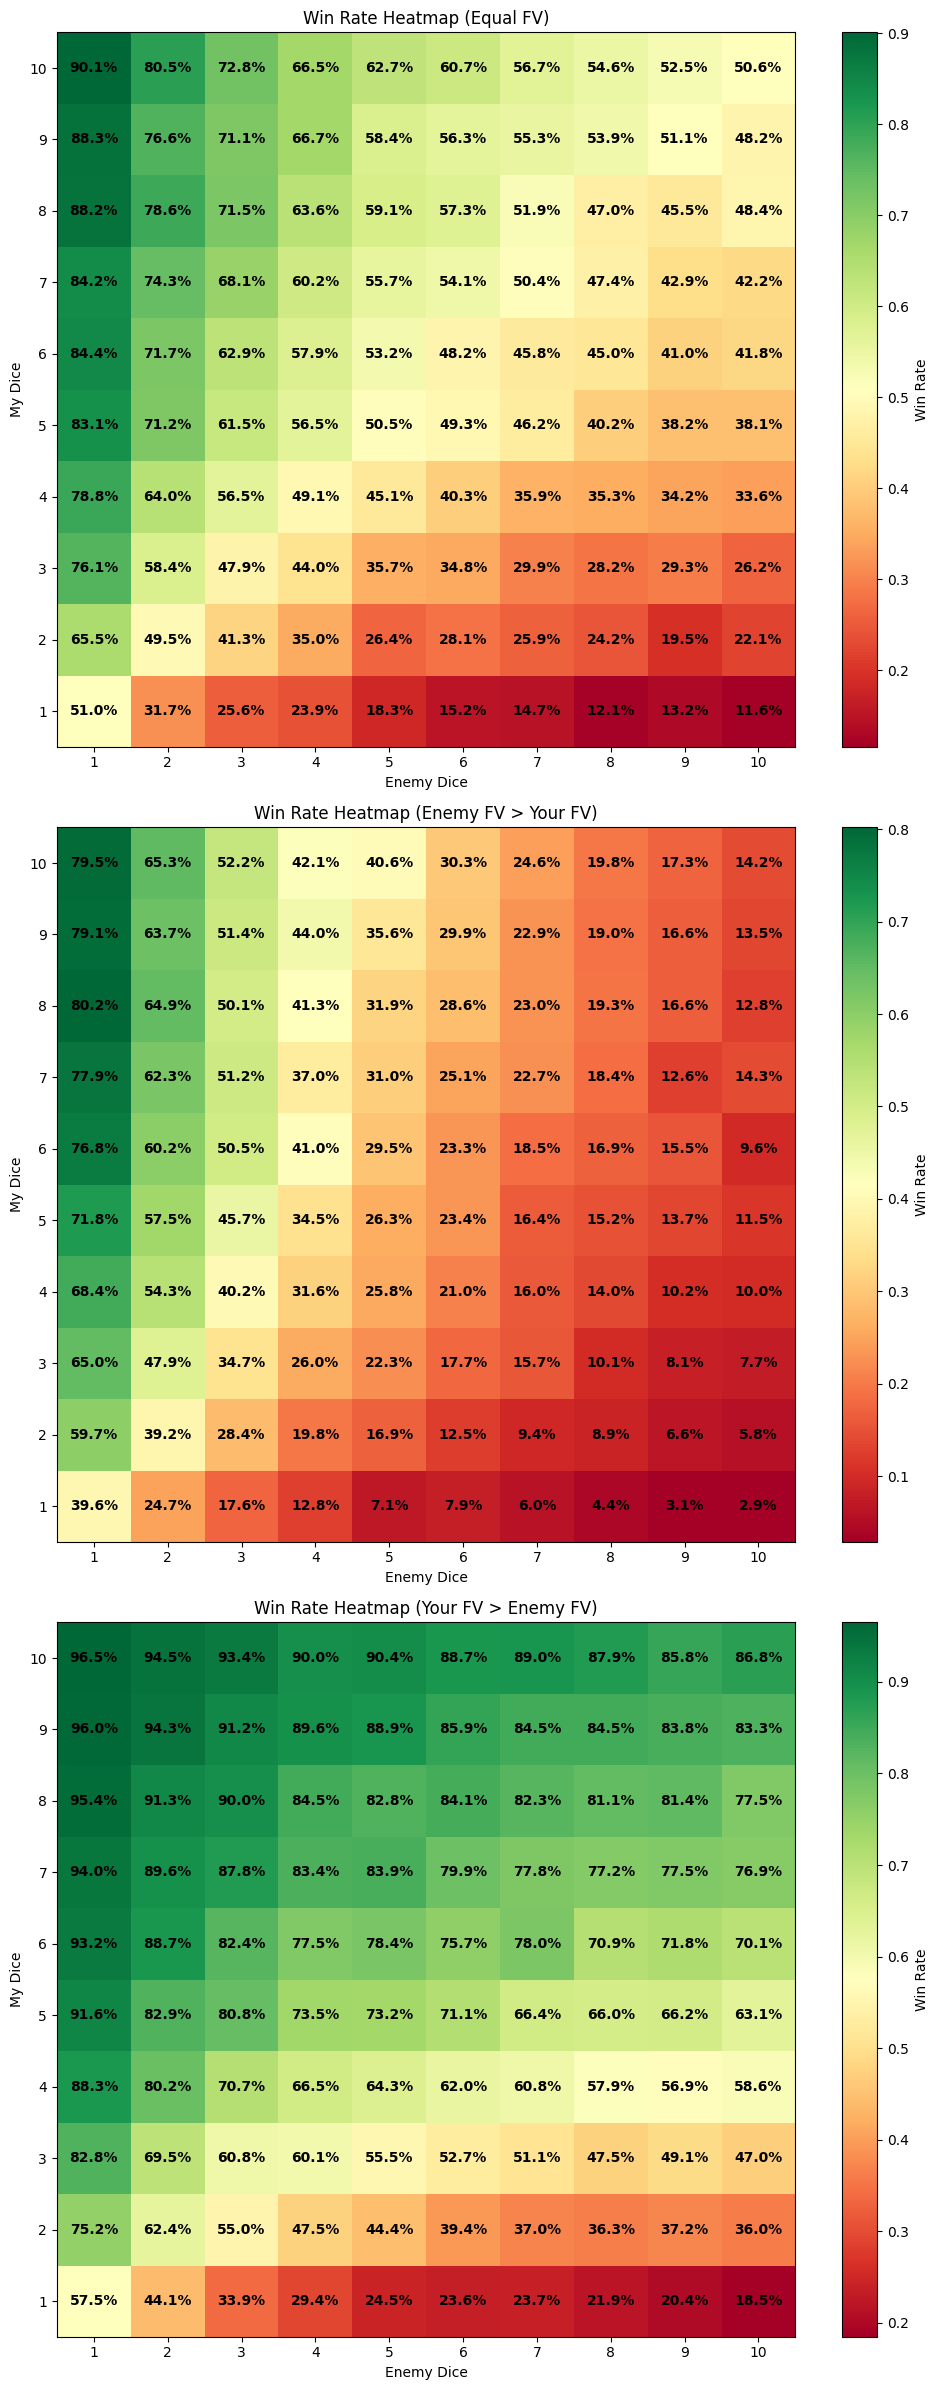

In [13]:
# Convert Win Rate to numeric for plotting
df['Win Rate Numeric'] = df['Win Rate'].str.rstrip('%').astype(float) / 100

# Get unique scenarios
scenarios = df['Scenario'].unique()

# Create subplots for each scenario in one column
fig, axes = plt.subplots(3, 1, figsize=(10, 24))

for i, scenario in enumerate(scenarios):
    df_scenario = df[df['Scenario'] == scenario]
    heatmap_data = df_scenario.pivot(index='My Dice', columns='Enemy Dice', values='Win Rate Numeric')
    
    im = axes[i].imshow(heatmap_data, cmap='RdYlGn', aspect='auto', origin='lower')
    
    # Add colorbar
    cbar = fig.colorbar(im, ax=axes[i], label='Win Rate')
    
    # Set labels and title
    axes[i].set_xlabel('Enemy Dice')
    axes[i].set_ylabel('My Dice')
    if scenario == "You have higher fight value":
        title = 'Win Rate Heatmap (Your FV > Enemy FV)'
    elif scenario == "Enemy has higher fight value":
        title = 'Win Rate Heatmap (Enemy FV > Your FV)'
    else:
        title = 'Win Rate Heatmap (Equal FV)'
    axes[i].set_title(title)
    
    # Add text annotations
    for x in range(len(heatmap_data.index)):
        for y in range(len(heatmap_data.columns)):
            value = heatmap_data.iloc[x, y]
            axes[i].text(y, x, f'{value:.1%}', ha='center', va='center',
                        color='black', fontweight='bold')
    
    axes[i].set_xticks(range(len(heatmap_data.columns)))
    axes[i].set_xticklabels(heatmap_data.columns)
    axes[i].set_yticks(range(len(heatmap_data.index)))
    axes[i].set_yticklabels(heatmap_data.index)

plt.tight_layout()
plt.show()